In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
from utils.common import extract_latents, save_model, load_model
from run_models import run_VAE, run_KMeans, run_DBSCAN, run_Agglomerative
from models.vae import VAE
from config import config

In [14]:
import torch, numpy as np
from pathlib import Path

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [16]:
root = Path("../..")

### Make sure config.MODEL_TYPE is 'conv'

In [17]:
config.MODEL_TYPE

'conv'

In [18]:
conv_vae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="conv", root=root, plot_dir_name="medium_1_conv_vae_audio_only")

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-20 15:58:13,888] A new study created in memory with name: Convolutional VAE Tuning





DATASET DIRECTORY: ..\..\data\features\en_bn



Creating fresh trials directory...


  0%|          | 0/2 [00:00<?, ?it/s]




SUGGESTED PARAMS: [('HIDDEN_DIM_3', 4), ('HIDDEN_DIM_2', 32), ('HIDDEN_DIM_1', 128), ('LATENT_DIM', 16), ('BETA_TYPE', 'fixed'), ('LR', 0.0001519934830130982), ('BATCH_SIZE', 64)]



VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv2d(4, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01, inplace=True)
      (6): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.01, inplace=True)
      (9): Flatten(start_dim=1, end_dim=-1)
    )
    (mu_layer): Linear(in_features=12288, ou

  0%|          | 0/2 [00:06<?, ?it/s]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 203.4990     | 195.9606    
Recon        | 194.5671     | 187.3922    
KL Div       | 8.9319       | 8.5685      
--------------------------------------------------

[I 2026-04-20 15:58:20,229] Trial 0 finished with value: 115.86267977627841 and parameters: {'CHANNEL_1': 4, 'CHANNEL_2_MULTIPLIER': 8, 'CHANNEL_3_MULTIPLIER': 4, 'LATENT_DIM': 16, 'LR': 0.0001519934830130982, 'BATCH_SIZE': 64}. Best is trial 0 with value: 115.86267977627841.


Best trial: 0. Best value: 115.863:  50%|█████     | 1/2 [00:06<00:06,  6.53s/it]




SUGGESTED PARAMS: [('HIDDEN_DIM_3', 8), ('HIDDEN_DIM_2', 64), ('HIDDEN_DIM_1', 512), ('LATENT_DIM', 32), ('BETA_TYPE', 'fixed'), ('LR', 0.00011615865989246468), ('BATCH_SIZE', 32)]



VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv2d(8, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01, inplace=True)
      (6): Conv2d(64, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.01, inplace=True)
      (9): Flatten(start_dim=1, end_dim=-1)
    )
    (mu_layer): Linear(in_features=49152, o

Best trial: 0. Best value: 115.863:  50%|█████     | 1/2 [00:15<00:06,  6.53s/it]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 141.8788     | 163.1614    
Recon        | 127.3443     | 153.1592    
KL Div       | 14.5345      | 10.0022     
--------------------------------------------------

[I 2026-04-20 15:58:29,744] Trial 1 finished with value: 95.89642116390235 and parameters: {'CHANNEL_1': 8, 'CHANNEL_2_MULTIPLIER': 8, 'CHANNEL_3_MULTIPLIER': 8, 'LATENT_DIM': 32, 'LR': 0.00011615865989246468, 'BATCH_SIZE': 32}. Best is trial 1 with value: 95.89642116390235.


Best trial: 1. Best value: 95.8964: 100%|██████████| 2/2 [00:16<00:00,  8.02s/it]
[W 2026-04-20 15:58:30,116] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.
[W 2026-04-20 15:58:30,117] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.
[W 2026-04-20 15:58:30,117] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.
[W 2026-04-20 15:58:30,118] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.
[W 2026-04-20 15:58:30,118] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.
[W 2026-04-20 15:58:30,118] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.
[W 2026-04-20 15:58:30,119] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.
[W 2026-04-20 15:58:30,119] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.
[W 2026-04-20 15:58:30,120] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.
[W 2026-04-20 15:58:30,120] Param CHANNEL_2_MULTIPLIER unique value length is less than 2.


..\..\results\trials\medium_1_conv_vae_audio_only\plots
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\optimization_history.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\param_importances.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\parallel_coordinate.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\edf.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\timeline.html
Saved: ..\..\results\trials\medium_1_conv_vae_audio_only\plots\contour.html
Best trial for `conv`:
Score: 95.8964
    CHANNEL_1                 8
    CHANNEL_2_MULTIPLIER      8
    CHANNEL_3_MULTIPLIER      8
    LATENT_DIM                32
    LR                        0.00011615865989246468
    BATCH_SIZE                32


FINAL MODEL:
 VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True

In [19]:
save_model(model=conv_vae, model_name="medium_1_conv_vae_audio_only", cfg=conv_vae.config, root=root)

Weights saved to : ..\..\results\models\medium_1_conv_vae_audio_only_20260420_155940.pt
Config saved to  : ..\..\results\models\medium_1_conv_vae_audio_only_20260420_155940_cfg.json


(WindowsPath('../../results/models/medium_1_conv_vae_audio_only_20260420_155940.pt'),
 WindowsPath('../../results/models/medium_1_conv_vae_audio_only_20260420_155940_cfg.json'))

In [24]:
conv_vae, best_trial_cfg = load_model(model_type="conv", weights_path=root/r"results\models\medium_1_conv_vae_audio_only_20260420_155940.pt", cfg_path=root/r"results\models\medium_1_conv_vae_audio_only_20260420_155940_cfg.json", device=device)

Model loaded from : ..\..\results\models\medium_1_conv_vae_audio_only_20260420_155940.pt
Config loaded from: ..\..\results\models\medium_1_conv_vae_audio_only_20260420_155940_cfg.json


In [25]:
conv_vae

VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv2d(8, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01, inplace=True)
      (6): Conv2d(64, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.01, inplace=True)
      (9): Flatten(start_dim=1, end_dim=-1)
    )
    (mu_layer): Linear(in_features=49152, out_features=32, bias=True)
    (logvar_layer): Linear(in_features=49152, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=49152, bias=Tr

In [26]:
train_latents, _ = extract_latents(model=conv_vae, loader=train_loader, device=device)
test_latents,  _  = extract_latents(model=conv_vae, loader=test_loader,  device=device)

In [27]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)

In [ ]:
vae_kmeans, vae_kmeans_metrics, vae_kmeans_df = run_KMeans(vae_latents, model_type="medium_1_conv_vae_audio_only", root=root)


KMeans best k      : 2
Silhouette         : 0.2975
CH Index           : 833.1845
DB Index           : 1.4327
Inertia            : 69132.0156
Cluster sizes      : {0: 695, 1: 2108}



In [32]:
vae_kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",500
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [35]:
vae_dbscan, vae_dbscan_metrics, vae_dbscan_df  = run_DBSCAN(vae_latents, model_type="medium_1_conv_vae_audio_only", root=root)


DBSCAN eps         : 2.2982
min_samples        : 10
Clusters found     : 2
Silhouette         : 0.5060
CH Index           : 63.4831
DB Index           : 0.5008
Coverage           : 0.8302
Noise ratio        : 0.1698
Cluster sizes      : {-1: 476, 0: 2317, 1: 10}



In [36]:
vae_dbscan

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",2.298160784927526
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",10
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [38]:
vae_agglomerative, vae_agglomerative_metrics, vae_agglomerative_df = run_Agglomerative(vae_latents, model_type="medium_1_conv_vae_audio_only", root=root)


Agglomerative best : k=2, linkage=complete, metric=euclidean
Silhouette         : 0.7269
CH Index           : 22.1519
DB Index           : 0.1945
Cluster sizes      : {0: 2802, 1: 1}



In [39]:
vae_agglomerative

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",2
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'complete'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [47]:
from visualizations import plot_latent_space_by_cluster, plot_latent_space_by_language

In [42]:
TSNE_DIR = root / config.TSNE_DIR
TSNE_DIR.mkdir(exist_ok=True, parents=True)

In [52]:
method = "tsne"

In [ ]:
plot_latent_space_by_cluster(
    latent_vecs=vae_latents,
    cluster_labels=vae_kmeans.labels_,
    method=method,
    save_path=TSNE_DIR/f"medium_1_conv_vae_audio_only_kmeans_{method}",
    plot_title=f"{method.upper()} Visualization of Convolutional VAE Clusters using K_Means (Audio Only)"
)

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [53]:
plot_latent_space_by_cluster(
    latent_vecs=vae_latents,
    cluster_labels=vae_dbscan.labels_,
    method=method,
    save_path=TSNE_DIR/f"medium_1_conv_vae_audio_only_dbscan_{method}",
    plot_title=f"{method.upper()} Visualization of Convolutional VAE Clusters using DB-SCAN (Audio Only)"
)

In [54]:
plot_latent_space_by_cluster(
    latent_vecs=vae_latents,
    cluster_labels=vae_agglomerative.labels_,
    method=method,
    save_path=TSNE_DIR/f"medium_1_conv_vae_audio_only_agglomerative_{method}",
    plot_title=f"{method.upper()} Visualization of Convolutional VAE Clusters using Agglomerative Clustering (Audio Only)"
)

In [ ]:
# # not sure how it works yet
# plot_latent_space_by_language(
#     latent_vecs=vae_latents,
#     languages=["en", "bn"],
#     method=method,
#     save_path=TSNE_DIR/f"medium_1_conv_vae_audio_only_by_language_{method}",
#     plot_title=f"{method.upper()} Visualization of Convolutional VAE Latent Vectors Clustered by Language (Audio Only)"
# )

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


IndexError: boolean index did not match indexed array along axis 0; size of axis is 2803 but size of corresponding boolean axis is 2

<Figure size 700x600 with 0 Axes>

Computing t-SNE embeddings (this may take a minute)...
Saved → ..\..\results\clustering\tsne\medium_1_conv_vae_audio_only


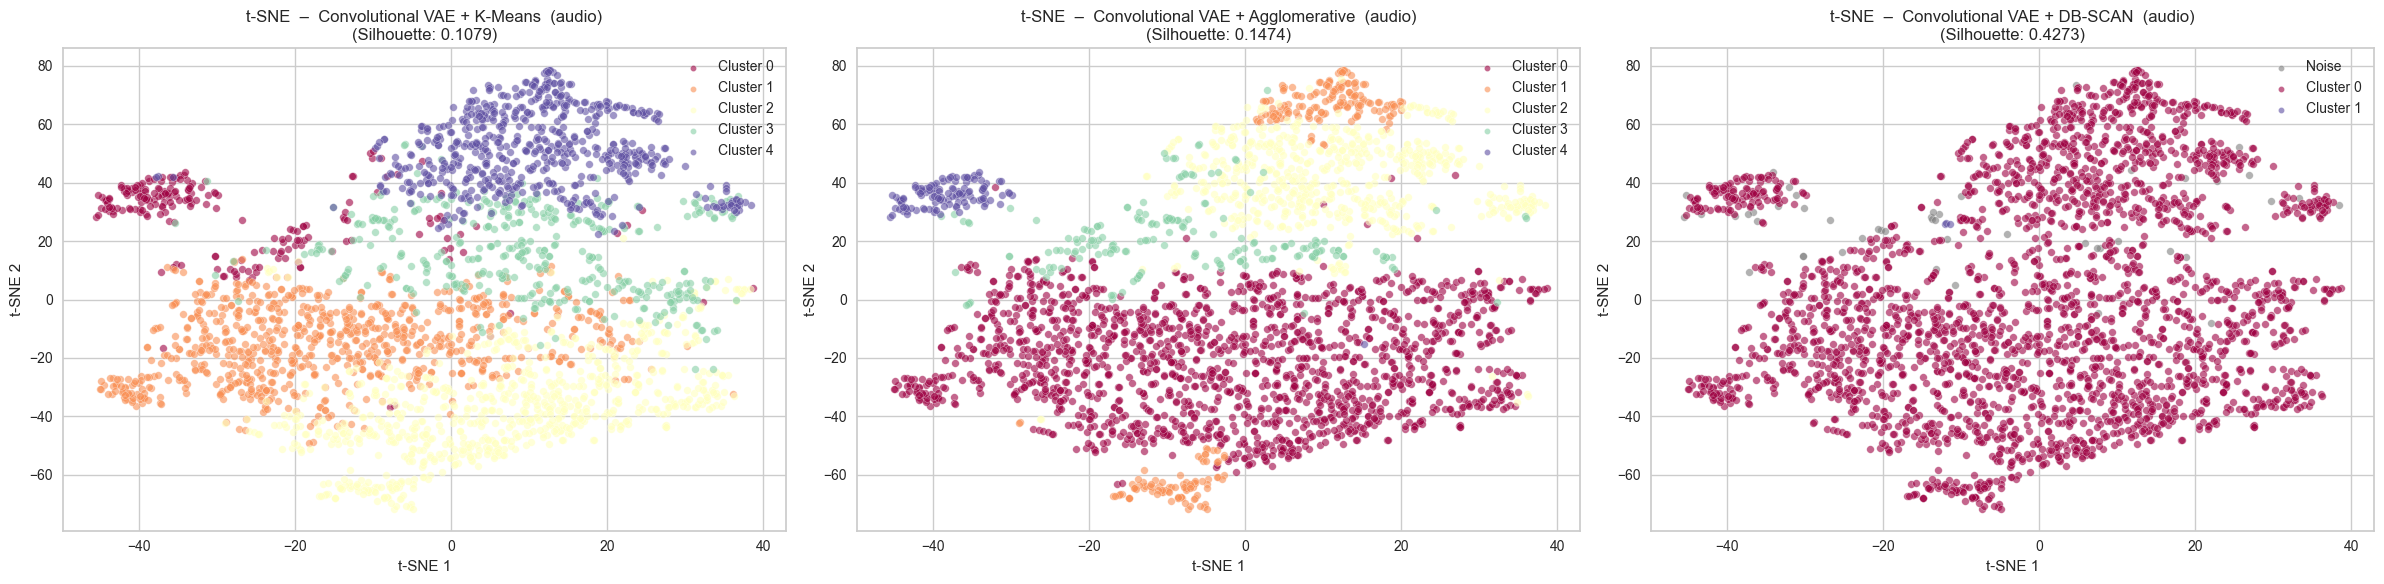

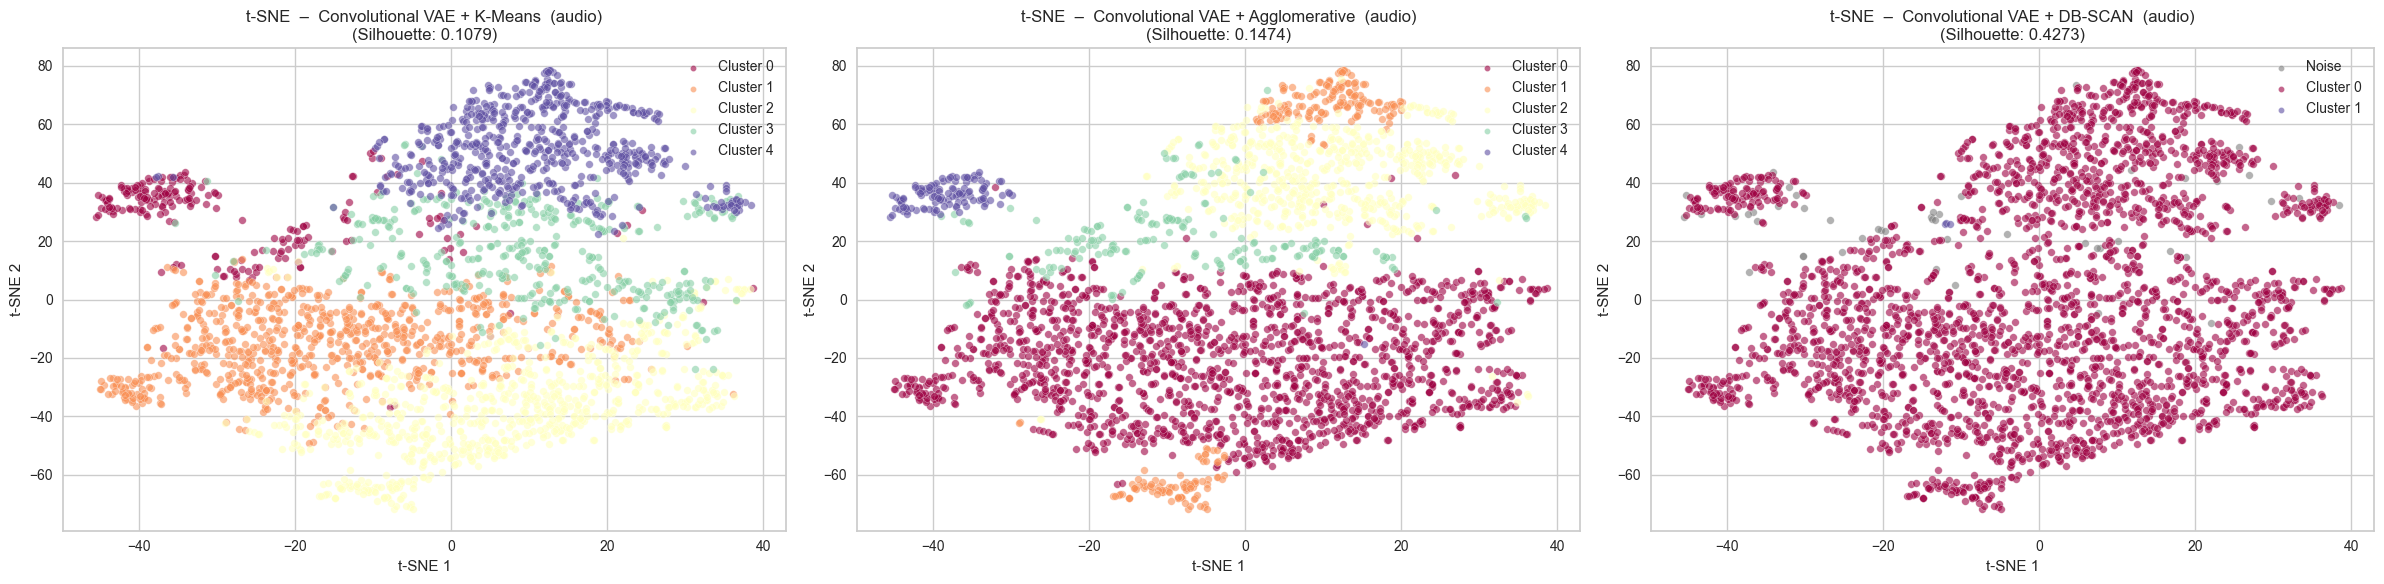

In [ ]:
plot_tsne_clustering_comparison(
    vae_latents,
    [vae_kmeans.labels_, vae_agglomerative.labels_, vae_dbscan.labels_],
    ["Convolutional VAE + K-Means  (audio)", "Convolutional VAE + Agglomerative  (audio)", "Convolutional VAE + DB-SCAN  (audio)"],
    scores=[silhouette_score(vae_latents, vae_kmeans.labels_), silhouette_score(vae_latents, vae_agglomerative.labels_), silhouette_score(vae_latents, vae_dbscan.labels_)],
    save_path=TSNE_DIR / "medium_1_conv_vae_audio_only"
)